<a href="https://colab.research.google.com/github/mmazurek-wat/ml-lab-edu/blob/main/ML_EN_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Lab

## 0. Setup



In [ ]:
# TODO:
# 1) Import required libraries (numpy, pandas, matplotlib)
# 2) Import sklearn components:
#    - datasets: load_breast_cancer
#    - model_selection: train_test_split, StratifiedKFold, cross_validate, GridSearchCV
#    - models: DecisionTreeClassifier, RandomForestClassifier
#    - metrics: classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay, brier_score_loss
#    - inspection: permutation_importance
# 3) Set RANDOM_STATE = 42

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay,
    PrecisionRecallDisplay,
    brier_score_loss
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

## 1. Data loading & exploration

In [ ]:
# TODO:
# 1) Load breast cancer dataset
# 2) Create X as DataFrame with feature names
# 3) Create y as Series
# 4) Print:
#    - shape of X
#    - class distribution (value_counts)
#    - head of X

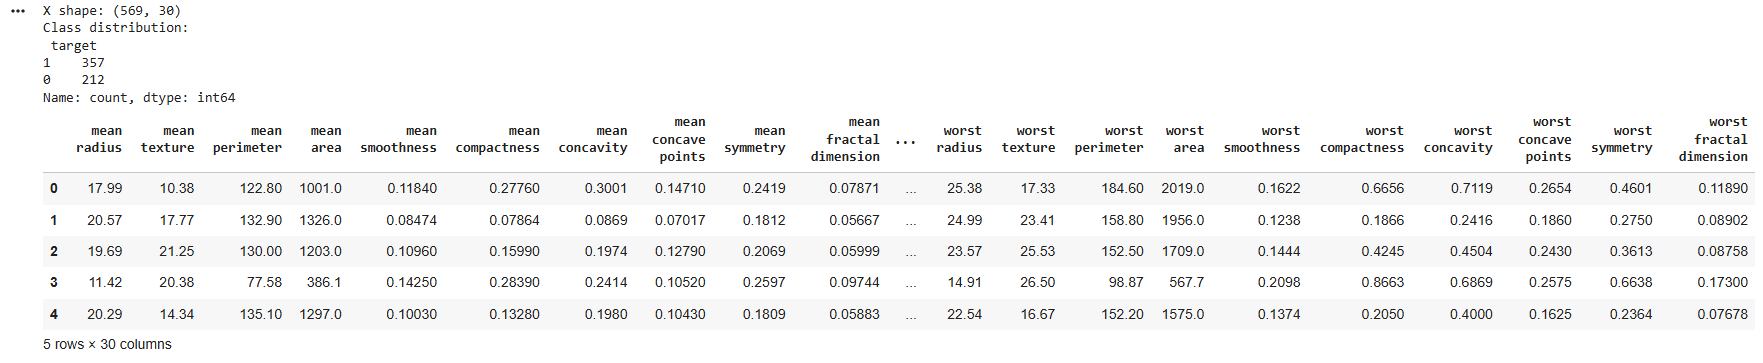

### Train/test split

In [ ]:
# TODO:
# 1) Split into train/test (test_size=0.25)
# 2) Use stratify=y and random_state=RANDOM_STATE
# 3) Print shapes of splits

# YOUR CODE HERE

## 2. Baseline model: Decision Tree

In [ ]:
# TODO:
# 1) Train a DecisionTreeClassifier(random_state=RANDOM_STATE)
# 2) Evaluate on test:
#    - classification_report
#    - confusion matrix plot
#    - ROC AUC (use predict_proba)

# YOUR CODE HERE

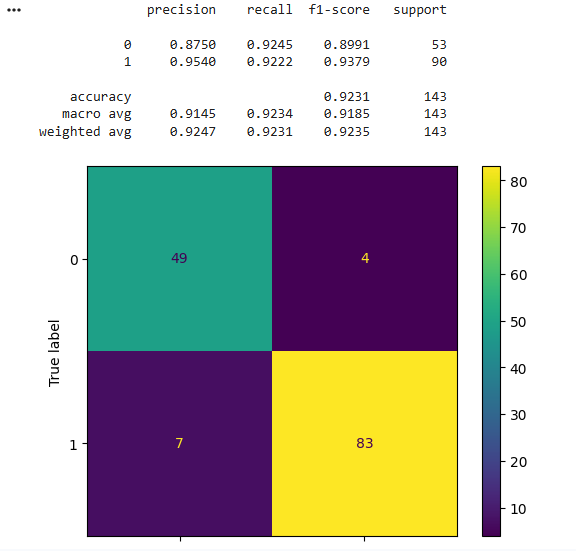

## 3. Random Forest baseline (minimal tuning)

In [ ]:
# TODO:
# 1) Train RandomForestClassifier with:
#    - n_estimators=300
#    - random_state=RANDOM_STATE
#    - n_jobs=-1
# 2) Evaluate similarly as in Part 2:
#    - classification_report
#    - confusion matrix plot
#    - ROC AUC
# 3) Compare against Decision Tree results (short comment)

# YOUR CODE HERE

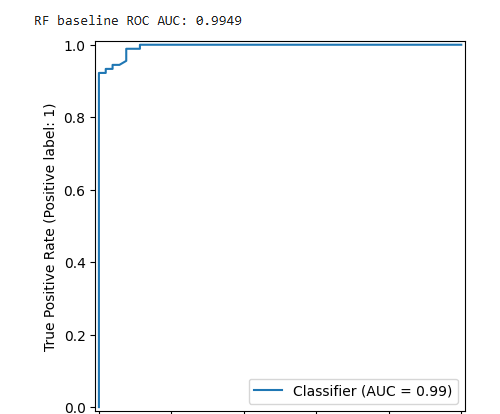

## 4. Cross-validation evaluation

In [ ]:
# TODO:
# 1) Create StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# 2) Use cross_validate on RF with scoring:
#    - "accuracy", "f1", "roc_auc"
# 3) Print mean ± std for each metric
# 4) Explain briefly why CV is needed even if test split exists

# YOUR CODE HERE

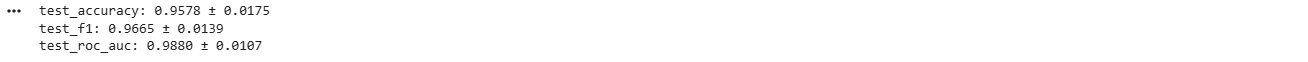

## 5. Hyperparameter tuning :GridSearchCV

In [ ]:
# TODO:
# 1) Create StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# 2) Use cross_validate on RF with scoring:
#    - "accuracy", "f1", "roc_auc"
# 3) Print mean ± std for each metric
# 4) Explain briefly why CV is needed even if test split exists

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 4, 8],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}


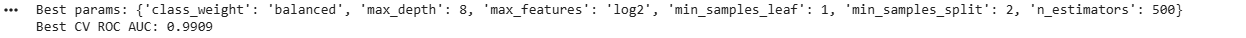

##  6. Evaluation on hold-out dataset

In [ ]:
# TODO:
# 1) Take best estimator from GridSearch
# 2) Evaluate on test:
#    - classification_report
#    - confusion matrix plot
#    - ROC curve plot
#    - PR curve plot
#    - ROC AUC
# 3) Compare tuned RF vs untuned RF (Part 3)

# YOUR CODE HERE

## 7.  OOB estimate vs CV vs test

In [ ]:
# TODO:
# 1) Train a RandomForestClassifier with oob_score=True
#    - use the best hyperparameters BUT set bootstrap=True (required for OOB)
# 2) Fit on TRAIN
# 3) Print:
#    - oob_score_
#    - CV mean roc_auc from GridSearch best_score_
#    - test roc_auc from Part 6
# 4) Short discussion: Why might OOB differ from CV/test?

## 8. Feature importance: impurity vs permutation

In [ ]:
# TODO:
# 1) Extract impurity-based feature_importances_ and show top-15 bar plot
# 2) Compute permutation_importance on TEST set:
#    - scoring="roc_auc"
#    - n_repeats=20
#    - random_state=RANDOM_STATE
# 3) Plot top-15 permutation importances with error bars (std)
# 4) Compare the two rankings: where do they differ and why?

## 9. Model behaviour: n_estimators sweep

In [ ]:
# TODO:
# 1) For n_estimators in [10, 30, 100, 300, 600]:
#    - train RF (keep other params fixed, e.g., best params except n_estimators)
#    - compute ROC AUC on train and test
# 2) Plot train vs test ROC AUC vs n_estimators


## 10. Calibration & uncertainty (Brier score)

In [ ]:
# TODO:
# 1) Compute a simple multiclass Brier score:
#    - one-hot encode y_test
#    - brier = mean over samples of sum_k (p_k - y_k)^2
# 2) Report it for tuned model